In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df=pd.read_csv("customer_support_tickets.csv")

In [3]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.shape

(8469, 17)

In [5]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [6]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
df['Resolution'] = df['Resolution'].fillna('Not Resolved')

In [8]:
df.duplicated().sum()

np.int64(0)

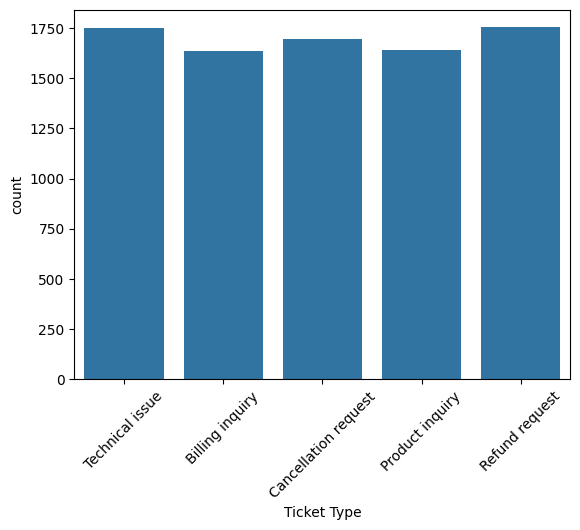

In [9]:
sns.countplot(x='Ticket Type', data=df)
plt.xticks(rotation=45)
plt.show()

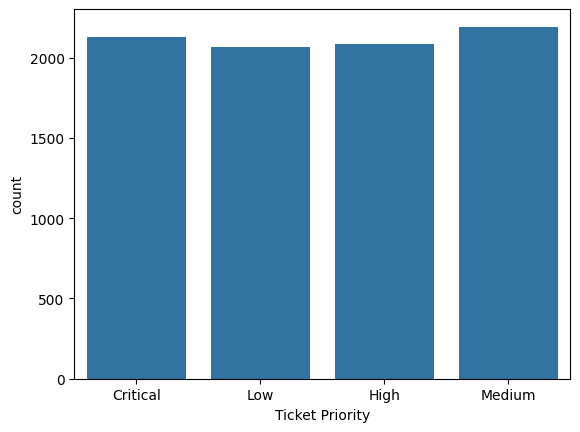

In [10]:
sns.countplot(x='Ticket Priority', data=df)
plt.show()

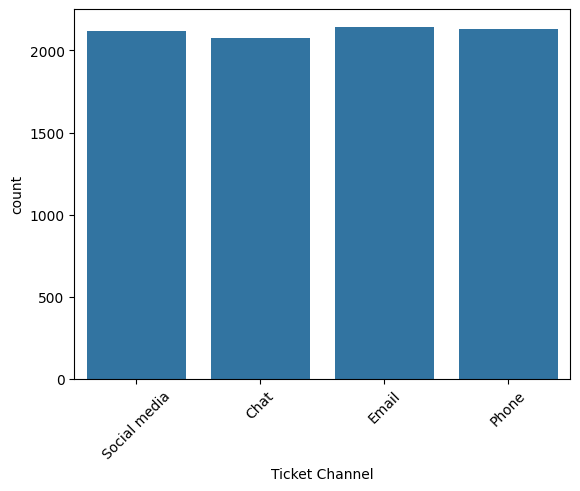

In [11]:
sns.countplot(x='Ticket Channel', data=df)
plt.xticks(rotation=45)
plt.show()

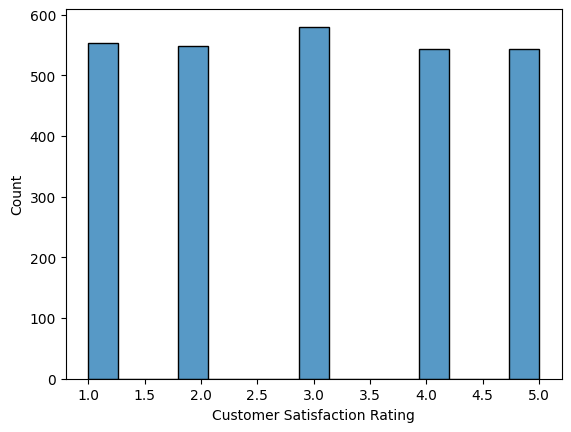

In [12]:
sns.histplot(df['Customer Satisfaction Rating'])
plt.show()

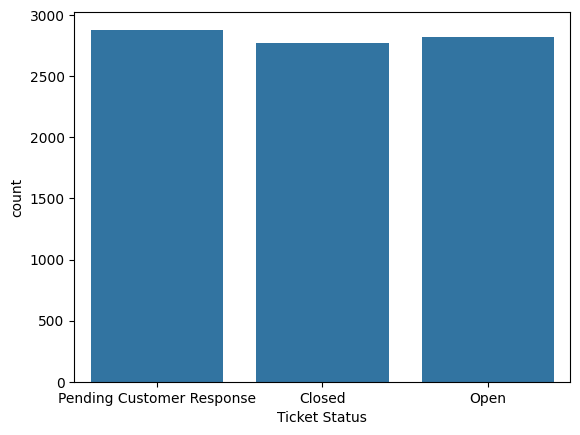

In [13]:
sns.countplot(x='Ticket Status', data=df)
plt.show()

In [18]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [20]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z\s]','',text)
    tokens=word_tokenize(text)
    tokens=[word for word in tokens if word not in stop_words]
    tokens=[lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [81]:
df['combined_text'] = (
    df['Ticket Subject'].astype(str) + ' ' +
    df['Ticket Description'].astype(str) + ' ' +
    df['Resolution'].astype(str)
)
df["Cleaned Text"]=df["Combined text"].apply(clean_text)

In [82]:
X=df['Cleaned Text']
y=df['Ticket Type']

In [88]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
from sklearn.pipeline import Pipeline


In [89]:
X_vectorized=tfidf.fit_transform(X)

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X_vectorized,y,test_size=0.2,random_state=42,stratify=y)

In [91]:
nb_model=MultinomialNB()

In [92]:
nb_model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [93]:
y_pred_nb=nb_model.predict(X_test)

In [94]:
print(classification_report(y_pred_nb,y_test))

                      precision    recall  f1-score   support

     Billing inquiry       0.13      0.20      0.16       217
Cancellation request       0.19      0.22      0.20       286
     Product inquiry       0.16      0.20      0.17       259
      Refund request       0.25      0.19      0.21       461
     Technical issue       0.30      0.22      0.25       471

            accuracy                           0.21      1694
           macro avg       0.20      0.21      0.20      1694
        weighted avg       0.22      0.21      0.21      1694



In [95]:
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [96]:
print(classification_report(y_pred_lr,y_test))

                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.22      0.21       313
Cancellation request       0.19      0.20      0.19       316
     Product inquiry       0.20      0.22      0.21       307
      Refund request       0.19      0.18      0.18       379
     Technical issue       0.28      0.26      0.27       379

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



In [97]:
svm_model = LinearSVC(C=1.5,class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [98]:
print(classification_report(y_pred_svm,y_test))

                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.22      0.22       331
Cancellation request       0.19      0.20      0.19       330
     Product inquiry       0.22      0.21      0.22       332
      Refund request       0.19      0.19      0.19       355
     Technical issue       0.24      0.24      0.24       346

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694

